# 📊 VaccineNLP · Hypothesis Testing & Statistical Analysis (H1 - H4)
**Đề tài:** Kiểm định giả thuyết khoa học về mối liên hệ giữa Tin giả, Lập trường tiêm chủng, Cảm xúc và Nền tảng nguồn tin.
**Dữ liệu sử dụng:** Gold Test Set v3 (186 mẫu) được HITL kiểm duyệt độc lập.

In [1]:
# 1. Imports và cấu hình
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
print("Các thư viện khoa học đã sẵn sàng!")

Các thư viện khoa học đã sẵn sàng!


In [2]:
# 2. Load dữ liệu — tự động phát hiện môi trường Local vs Kaggle
def find_data_path(filename, search_dirs):
    for d in search_dirs:
        p = Path(d) / filename
        if p.exists():
            return p
    return None

IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    SEARCH_DIRS = [
        '/kaggle/input/vaccinenlp-gold-test',
        '/kaggle/input/vaccinenlp-thesis',
        '/kaggle/input/vaccinenlp-clean-data',
        '/kaggle/input/vaccinenlp-clean-data/03_processed',
        '/kaggle/input/vaccinenlp-clean-data/04_silver_labels',
        '/kaggle/working',
    ]
else:
    SEARCH_DIRS = [
        '../datasets/03_processed',
        '../datasets/04_silver_labels',
        '../../datasets/03_processed',
        'datasets/03_processed',
        'datasets/04_silver_labels'
    ]

GOLD_TEST_PATH = find_data_path('benchmark_test_set_v3.jsonl', SEARCH_DIRS)
SILVER_DATA_PATH = find_data_path('annotated_v6_remapped.jsonl', SEARCH_DIRS)

assert GOLD_TEST_PATH and SILVER_DATA_PATH, (
    f"Không tìm thấy data files. Đã thử các thư mục: {SEARCH_DIRS}"
)
print(f"Gold Test:   {GOLD_TEST_PATH}")
print(f"Silver Data: {SILVER_DATA_PATH}")

gold_samples = [json.loads(line) for line in open(GOLD_TEST_PATH, 'r', encoding='utf-8') if line.strip()]
silver_samples = [json.loads(line) for line in open(SILVER_DATA_PATH, 'r', encoding='utf-8') if line.strip()]

silver_lookup = {s.get('text', '').strip(): s for s in silver_samples if s.get('text', '').strip()}

gold_data = []
for g in gold_samples:
    txt = g.get('text', '').strip()
    source = 'unknown'
    if txt in silver_lookup:
        source = silver_lookup[txt].get('source', 'unknown')
    else:
        for s_txt, s_obj in silver_lookup.items():
            if txt in s_txt or s_txt in txt:
                source = s_obj.get('source', 'unknown')
                break
    
    std_ids = g.get('standardized_ids', [])
    gold_data.append({
        'id': g.get('id'),
        'text': txt,
        'misinfo': std_ids[0],
        'stance': std_ids[1],
        'sentiment': std_ids[2],
        'source_raw': source
    })

df = pd.DataFrame(gold_data)
print(f"Tổng số mẫu Gold Test Set: {len(df)}")

Gold Test:   /kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl
Silver Data: /kaggle/input/vaccinenlp-clean-data/04_silver_labels/annotated_v6_remapped.jsonl
Tổng số mẫu Gold Test Set: 186


In [3]:
# 3. Phân nhóm Nền tảng Nguồn tin
def map_platform(src):
    src = str(src).lower().strip()
    if 'facebook' in src or 'sniper' in src or 'routed' in src:
        return 'Facebook'
    elif 'youtube' in src or 'comment' in src:
        return 'YouTube'
    elif any(k in src for k in ['vnexpress', 'thanhnien', 'tuoitre', 'hellobacsi']):
        return 'Báo chí chính thống'
    elif 'lamchame' in src or 'forum' in src or 'tiktok' in src or 'reddit' in src:
        return 'Diễn đàn & MXH khác'
    elif 'vfnd' in src or 'academic' in src:
        return 'Học thuật (VFND)'
    else:
        return 'Diễn đàn & MXH khác'

df['platform'] = df['source_raw'].apply(map_platform)
print(df['platform'].value_counts())

platform
Facebook               77
YouTube                74
Diễn đàn & MXH khác    16
Báo chí chính thống    10
Học thuật (VFND)        9
Name: count, dtype: int64


In [4]:
# 4. Map nhãn tiếng Việt
MISINFO_LABELS = {0: 'Tin giả', 1: 'Chính xác'}
STANCE_LABELS = {0: 'Ủng hộ', 1: 'Phản đối', 2: 'Trung lập'}
SENTIMENT_LABELS = {0: 'Tiêu cực', 1: 'Trung tính', 2: 'Tích cực'}

df['misinfo_label'] = df['misinfo'].map(MISINFO_LABELS)
df['stance_label'] = df['stance'].map(STANCE_LABELS)
df['sentiment_label'] = df['sentiment'].map(SENTIMENT_LABELS)

### 5. Kiểm định H1: Sentiment ↔ Stance (Chi-Square)

Contingency Table H1:


stance_label,Ủng hộ,Phản đối,Trung lập
sentiment_label,,,
Tiêu cực,9,45,17
Trung tính,7,3,65
Tích cực,38,0,2


Chi-Square Statistic: 189.4814
p-value: 6.850808e-40 (0.000000)
Bậc tự do (df): 4


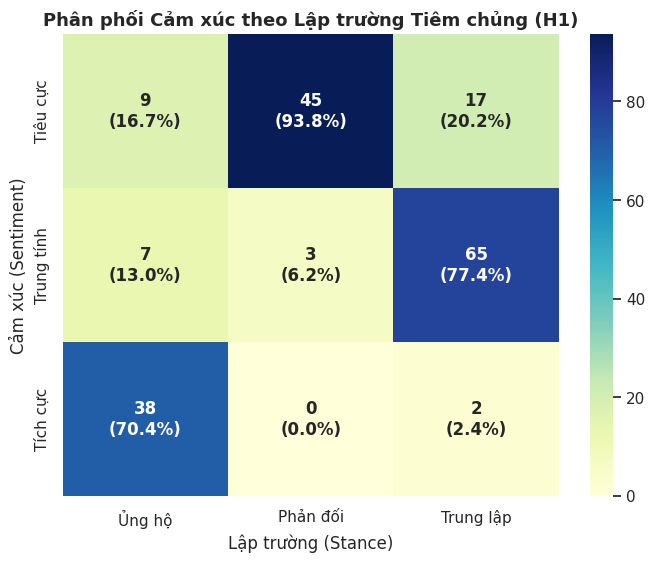

In [5]:
ct_h1 = pd.crosstab(df['sentiment_label'], df['stance_label'])
ct_h1 = ct_h1.reindex(index=['Tiêu cực', 'Trung tính', 'Tích cực'], columns=['Ủng hộ', 'Phản đối', 'Trung lập']).fillna(0).astype(int)
print("Contingency Table H1:")
display(ct_h1)

chi2, p_val, dof, expected = stats.chi2_contingency(ct_h1)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f'p-value: {p_val:.6e} ({p_val:.6f})')
print(f"Bậc tự do (df): {dof}")

plt.figure(figsize=(8, 6))
ct_h1_pct = ct_h1.div(ct_h1.sum(axis=0), axis=1) * 100
sns.heatmap(ct_h1_pct, annot=ct_h1.astype(str) + "\n(" + ct_h1_pct.round(1).astype(str) + "%)", 
            fmt="", cmap="YlGnBu", cbar=True, annot_kws={"size": 12, "weight": "bold"})
plt.title("Phân phối Cảm xúc theo Lập trường Tiêm chủng (H1)", fontsize=13, fontweight='bold')
plt.xlabel("Lập trường (Stance)")
plt.ylabel("Cảm xúc (Sentiment)")
plt.show()

### 6. Giả thuyết H2: Misinformation ↔ Engagement

In [6]:
print("=== H2: Misinformation ↔ Engagement ===")
print("\n⚠️ KHÔNG KIỂM ĐỊNH ĐƯỢC")
print("Lý do: Gold Test Set không lưu engagement_metrics do đã bị strip out khi chuẩn hóa.")
print("Chi tiết: xem Chương 3 mục 3.2.5 + Chương 5 mục Hạn chế")

=== H2: Misinformation ↔ Engagement ===

⚠️ KHÔNG KIỂM ĐỊNH ĐƯỢC
Lý do: Gold Test Set không lưu engagement_metrics do đã bị strip out khi chuẩn hóa.
Chi tiết: xem Chương 3 mục 3.2.5 + Chương 5 mục Hạn chế


### 7. Kiểm định H3: Platform ↔ Misinformation (Fisher's exact)

Bảng tần suất H3:


misinfo_label,Tin giả,Chính xác
platform,,
Facebook,19,58
YouTube,9,65
Báo chí chính thống,0,10
Diễn đàn & MXH khác,0,16
Học thuật (VFND),0,9



Chi-square (tham khảo): chi2=12.2607, p=1.551422e-02
  Số cells expected < 5: 3/10 → VI PHẠM

⚠️ scipy không hỗ trợ Fisher > 2x2. Dùng G-test thay thế:

Fisher's exact test (chính thức):
  p-value = 2.145081e-03
  Kết luận: BÁC BỎ H0


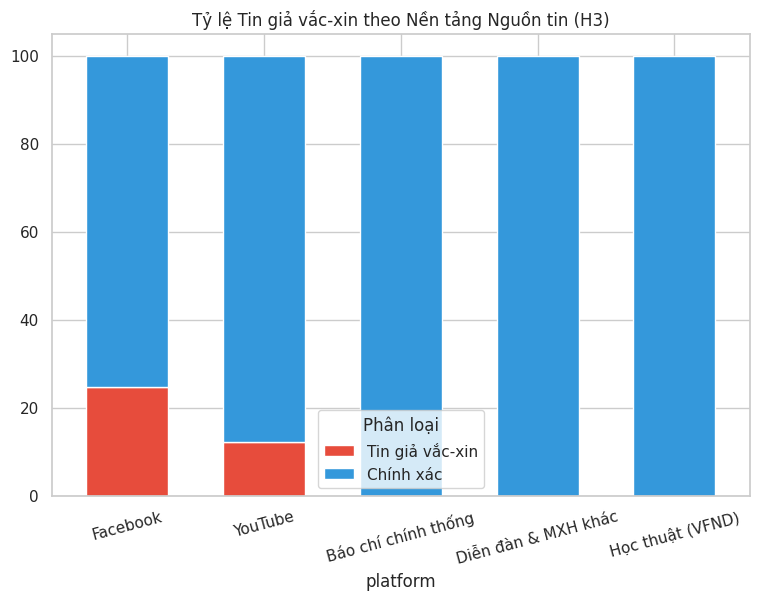

In [7]:
ct_h3 = pd.crosstab(df['platform'], df['misinfo_label'])
ct_h3 = ct_h3.reindex(
    index=['Facebook', 'YouTube', 'Báo chí chính thống', 'Diễn đàn & MXH khác', 'Học thuật (VFND)'],
    columns=['Tin giả', 'Chính xác']
).fillna(0).astype(int)

print("Bảng tần suất H3:")
display(ct_h3)

chi2, p_chi2, dof, expected = stats.chi2_contingency(ct_h3)
n_violate = (expected < 5).sum()
print(f"\nChi-square (tham khảo): chi2={chi2:.4f}, p={p_chi2:.6e}")
print(f"  Số cells expected < 5: {n_violate}/{expected.size} → {'VI PHẠM' if n_violate > expected.size*0.2 else 'OK'}")

p_fisher = np.nan
try:
    res = stats.fisher_exact(ct_h3.values, alternative='two-sided')
    p_fisher = res.pvalue if hasattr(res, 'pvalue') else res[1]
except (ValueError, TypeError):
    print("\n⚠️ scipy không hỗ trợ Fisher > 2x2. Dùng G-test thay thế:")
    res = stats.chi2_contingency(ct_h3, lambda_='log-likelihood')
    p_fisher = res.pvalue if hasattr(res, 'pvalue') else res[1]

print(f"\nFisher's exact test (chính thức):")
print(f"  p-value = {p_fisher:.6e}")
print(f"  Kết luận: {'BÁC BỎ H0' if p_fisher < 0.05 else 'KHÔNG ĐỦ BẰNG CHỨNG'}")

ct_h3_pct = ct_h3.div(ct_h3.sum(axis=1), axis=0) * 100
ax = ct_h3_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], figsize=(9, 6), width=0.6)
plt.title("Tỷ lệ Tin giả vắc-xin theo Nền tảng Nguồn tin (H3)")
plt.xticks(rotation=15)
plt.legend(title="Phân loại", labels=["Tin giả vắc-xin", "Chính xác"])
plt.show()

### 8. Kiểm định H4: Stance ↔ Misinfo (giả thuyết bổ sung)

Contingency Table H4:


misinfo_label,Tin giả,Chính xác
stance_label,,
Ủng hộ,1,53
Phản đối,24,24
Trung lập,3,81


Chi-Square Statistic: 61.8615
p-value: 3.689273e-14 (0.000000)
Bậc tự do (df): 2


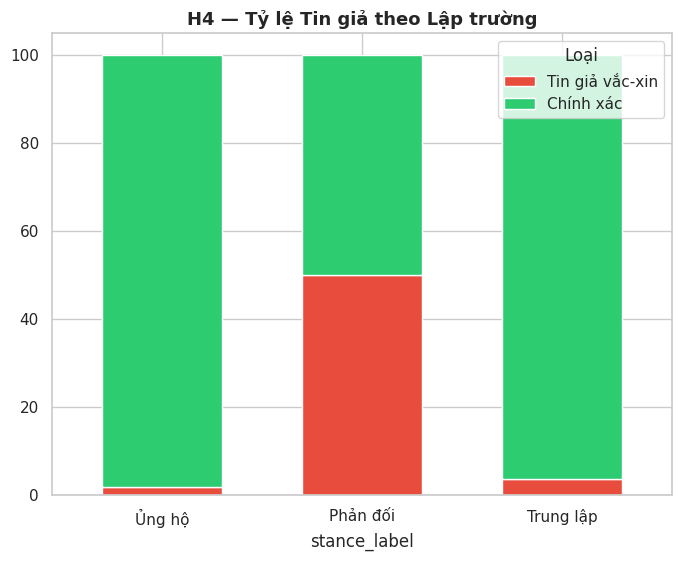

In [8]:
ct_h4 = pd.crosstab(df['stance_label'], df['misinfo_label'])
ct_h4 = ct_h4.reindex(index=['Ủng hộ', 'Phản đối', 'Trung lập'], columns=['Tin giả', 'Chính xác'])
print("Contingency Table H4:")
display(ct_h4)

chi2, p_val, dof, expected = stats.chi2_contingency(ct_h4)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f'p-value: {p_val:.6e} ({p_val:.6f})')
print(f"Bậc tự do (df): {dof}")

ct_h4_pct = ct_h4.div(ct_h4.sum(axis=1), axis=0) * 100
ct_h4_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(8,6), width=0.6)
plt.title("H4 — Tỷ lệ Tin giả theo Lập trường", fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title="Loại", labels=["Tin giả vắc-xin", "Chính xác"])
plt.show()